========== RAW HR ==========
Mean      : 75.09649459631277
Std       : 10.736697505251097
Spikes    : 224
Noise     : 0.3000398582891357
Drift     : -0.0011579986425533173

========== FILTERED HR ==========
Mean      : 75.09649217195201
Std       : 10.736027595230649
Spikes    : 223
Noise     : 0.2690668136252866
Drift     : -0.0011579963662164282

========== IMPROVEMENT ==========
Noise Reduction (%) : 10.322976700649447
Std Reduction (%) : 0.006239442064200317


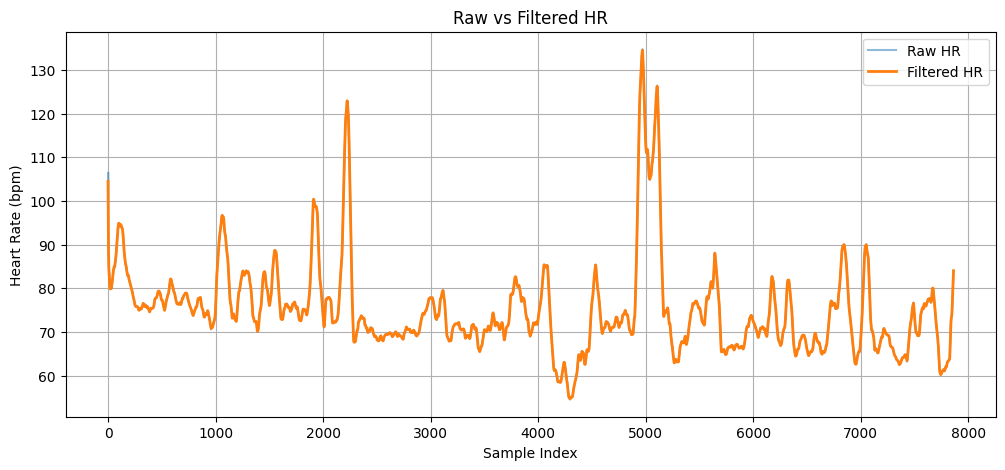

In [4]:
import numpy as np
from scipy.signal import savgol_filter
from scipy.stats import zscore
from scipy.signal import find_peaks
from scipy.stats import linregress

# ---------------------------------
# FILTER HR
# ---------------------------------

hr_filtered = savgol_filter(
    hr,
    window_length=11,  # must be odd
    polyorder=2
)

# ---------------------------------
# QUALITY METRICS
# ---------------------------------

def calculate_noise(signal):
    return np.std(np.diff(signal))

def count_spikes(signal, threshold=3):
    z = np.abs(zscore(signal))
    return np.sum(z > threshold)

def calculate_drift(signal):
    x = np.arange(len(signal))
    slope, _, _, _, _ = linregress(x, signal)
    return slope

# ---------------------------------
# RAW METRICS
# ---------------------------------

raw_mean = np.mean(hr)
raw_std = np.std(hr)
raw_noise = calculate_noise(hr)
raw_spikes = count_spikes(hr)
raw_drift = calculate_drift(hr)

# ---------------------------------
# FILTERED METRICS
# ---------------------------------

filt_mean = np.mean(hr_filtered)
filt_std = np.std(hr_filtered)
filt_noise = calculate_noise(hr_filtered)
filt_spikes = count_spikes(hr_filtered)
filt_drift = calculate_drift(hr_filtered)

# ---------------------------------
# RESULTS
# ---------------------------------

print("========== RAW HR ==========")
print("Mean      :", raw_mean)
print("Std       :", raw_std)
print("Spikes    :", raw_spikes)
print("Noise     :", raw_noise)
print("Drift     :", raw_drift)

print("\n========== FILTERED HR ==========")
print("Mean      :", filt_mean)
print("Std       :", filt_std)
print("Spikes    :", filt_spikes)
print("Noise     :", filt_noise)
print("Drift     :", filt_drift)

print("\n========== IMPROVEMENT ==========")
print("Noise Reduction (%) :",
      ((raw_noise - filt_noise)/raw_noise)*100)

print("Std Reduction (%) :",
      ((raw_std - filt_std)/raw_std)*100)

# ---------------------------------
# PLOT
# ---------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(hr, label="Raw HR", alpha=0.5)

plt.plot(
    hr_filtered,
    label="Filtered HR",
    linewidth=2
)

plt.title("Raw vs Filtered HR")
plt.xlabel("Sample Index")
plt.ylabel("Heart Rate (bpm)")

plt.legend()
plt.grid()

plt.show()

HR Filtering Analysis – Key Findings
1. Heart Rate Trend Was Preserved
Mean HR remained almost unchanged:
Raw: 75.10 bpm
Filtered: 75.10 bpm
This indicates that filtering did not alter the physiological information contained in the signal.
2. Noise Was Reduced
Noise estimate decreased from:
0.3000 → 0.2691
Noise reduction achieved:
10.32%
This shows that the filter successfully removed minor fluctuations and measurement noise.
3. Variability Remained Stable
Standard deviation changed only slightly:
10.7367 → 10.7360
Reduction:
0.006%
Therefore, the natural variability of the heart rate signal was preserved.
4. Outliers Were Largely Unaffected
Spike count changed only:
224 → 223
This indicates that the HR signal already contained very few noise-induced artifacts.
5. Long-Term Trend Was Maintained
Drift slope remained nearly identical:
Raw: −0.001158
Filtered: −0.001158
Therefore, filtering preserved the overall temporal behavior of the signal.